In [3]:
%cd ..

/scratch/big/home/daawic/BSc-Thesis


In [4]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import transforms
from project.models import EDMCallum
from project.util.device import get_available_acc
from project.util.plotting import plot_sample
from project.util.data import ReplayMemoryData
from project.util.transforms import Difference

In [5]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")

In [6]:
device = "cuda:2"

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    Difference(),
    transforms.Normalize(0.5, 0.5),
])

In [8]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=1_000_000
)

In [16]:
model = EDMCallum.from_checkpoint(PATH, device, U=10).to(device)

In [26]:
x = torch.zeros((4, 7, 88, 88), device=device)

for i, img in enumerate(torch.randperm(500_000)[:4]):
    x[i] = data[img + 500_000].to(device)

In [27]:
mask = torch.ones_like(x, device=device)
channels = torch.tensor([2, 3, 5, 6])
mask[:, channels,] = 0

In [28]:
x_masked = x * mask

In [29]:
x.shape, mask.shape

(torch.Size([4, 7, 88, 88]), torch.Size([4, 7, 88, 88]))

In [30]:
x_inpainted = model.inpaint(x, mask)

100%|██████████| 32/32 [00:39<00:00,  1.25s/it]


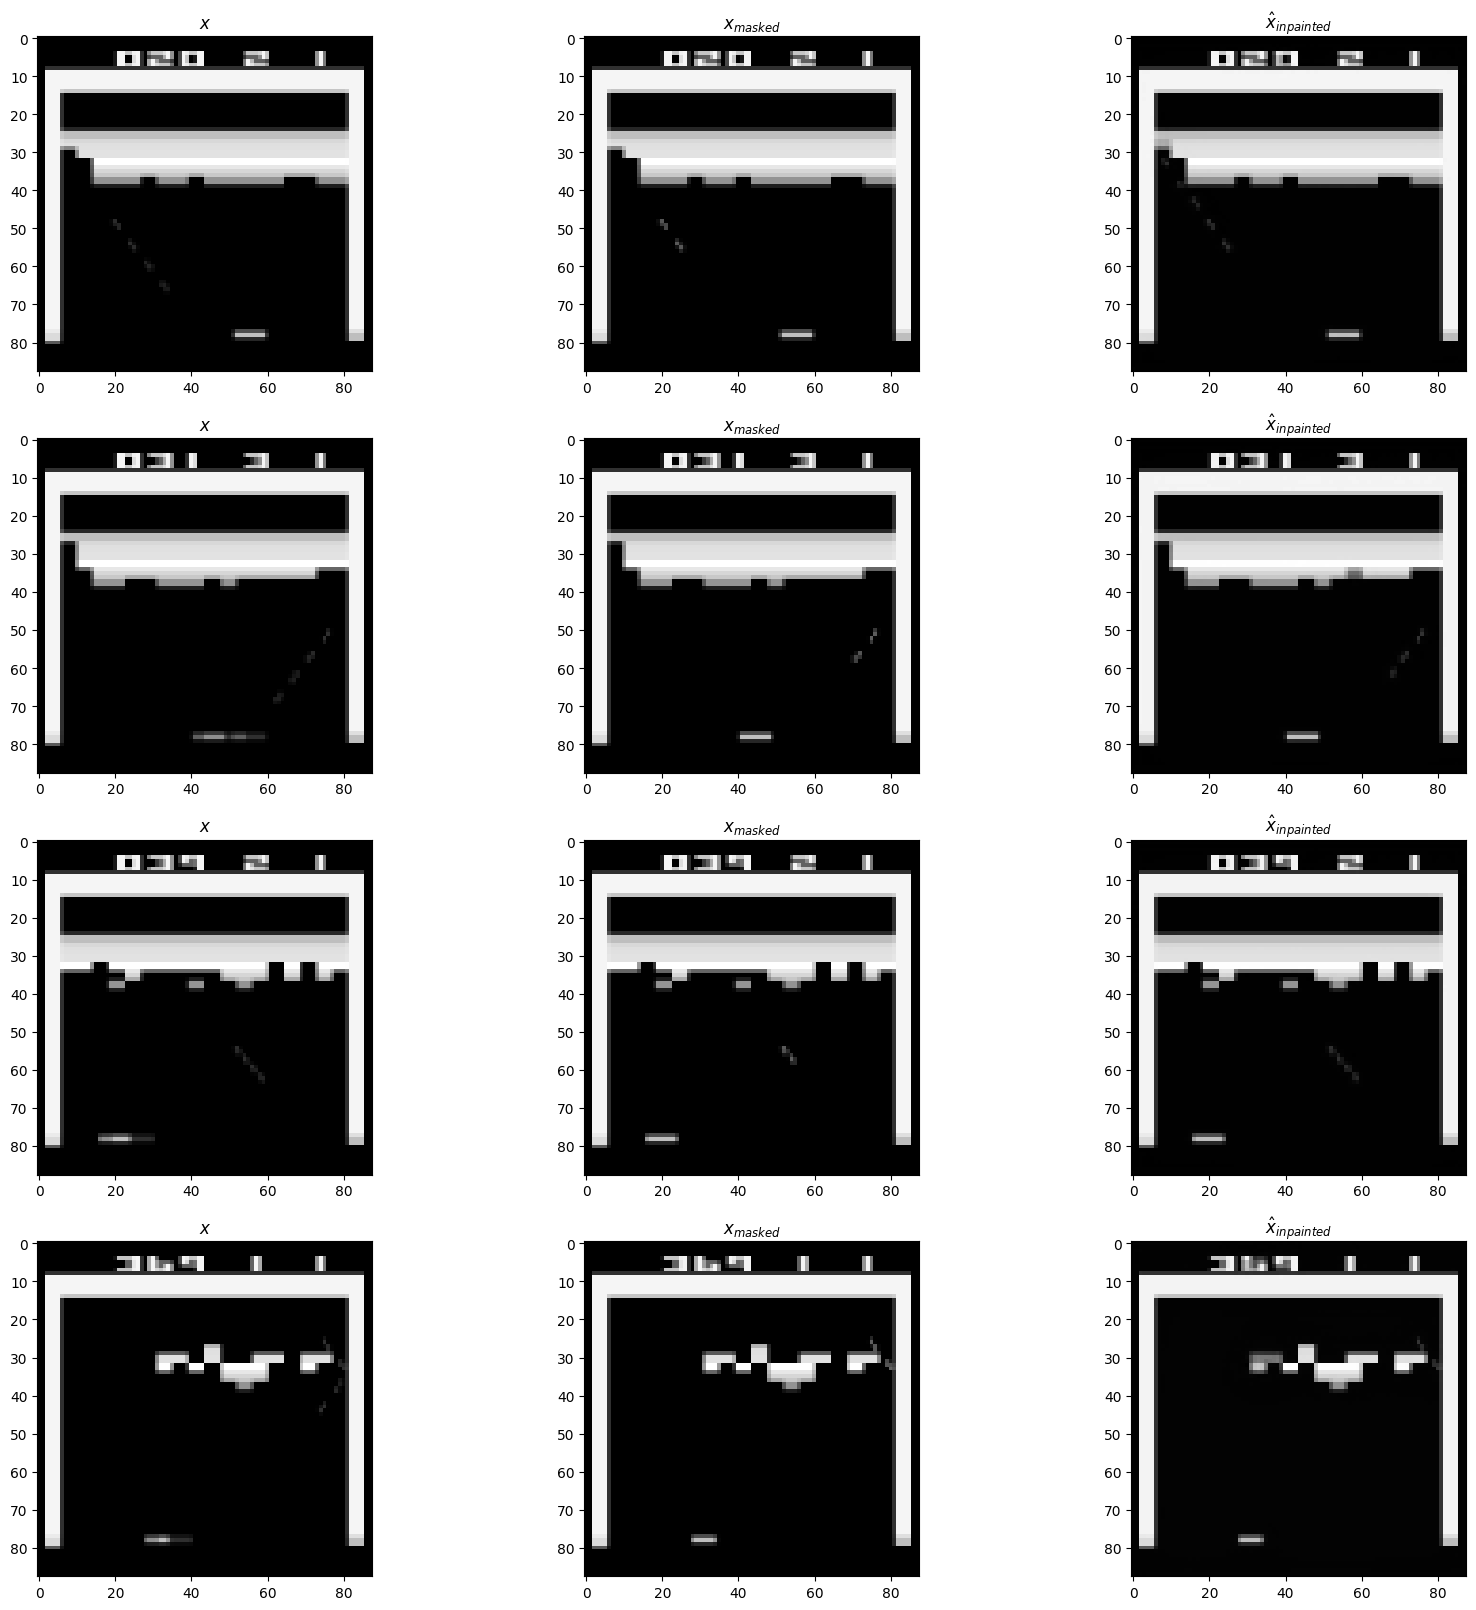

In [31]:
fig, axis = plt.subplots(4, 3, figsize=(20, 20))

for i in range(4):
    axis[i, 0].imshow(x[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 1].imshow(x_masked[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 2].imshow(x_inpainted[i, :4].mean(dim=0).to("cpu"), cmap='grey')
    axis[i, 0].set_title("$x$")
    axis[i, 1].set_title("$x_{masked}$")
    axis[i, 2].set_title("$\\hat{x}_{inpainted}$")

plt.show()